# FX VALIDATION

For context to this analysis and graph we refer you to https://docs.google.com/document/d/1MxF69SCqr3JYGorkFOOj0GVdvsZTgOGLjBADEKK1xuY/edit?tab=t.0#heading=h.4518ca4obgqv


In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import matplotlib.ticker as mtick

from datetime import datetime
import os
import sys

current_directory = os.getcwd()
risk_pylibrary_path = current_directory.replace('user_libs/fgv31/RMT_validations','')
repo_path = current_directory.replace('risk_pylibrary/user_libs/fgv31/RMT_validations','')

sys.path.append(repo_path)
sys.path.append(risk_pylibrary_path)


import tools.snowflake_db.db_connection as db

In [2]:


sql_query_fx_total = """ --sql
WITH corporate_transaction_accounts_exposure as 
(
    select
        report_date,
        'Corporate Transaction Accounts' as account_type,
        concat(
        'corp-',
        to_char(report_date, 'yyyymmdd')
        ) as surrogate_key,
        sum(amount_in_euro) as amount_in_euro
    from
        teams_prd.risk_management_transform.trf__risk_management__fx_corporate_transactions_daily_exposures
    group by 
        report_date
),

-- Daily open currency expoure of non-euro accounts from trading book
trading_book_accounts_exposure as 
(
    select
        report_date,
        'Trading Book Accounts' as account_type,
        concat(
        'trad-',
        to_char(report_date, 'yyyymmdd')
        ) as surrogate_key,
        sum(amount_in_euro) as amount_in_euro
    from
        teams_prd.risk_management_transform.trf__risk_management__fx_trading_book_daily_exposures
    group by 
        report_date
),

-- Daily open currency expoure of non-euro securities services accounts
securities_services_accounts_exposure as 
(
    select
        report_date,
        'Securities Services Accounts' as account_type,
        concat(
        'sec-',
        to_char(report_date, 'yyyymmdd')
        ) as surrogate_key,
        sum(amount_in_euro) as amount_in_euro
    from
        teams_prd.risk_management_transform.trf__risk_management__fx_securities_services_daily_exposures
    group by 
        report_date
)

-- Daily open currnecy expoure of non-euro accounts
select
    *
from
    trading_book_accounts_exposure

union all

select
    *
from
    corporate_transaction_accounts_exposure
union all

select
    *
from
    securities_services_accounts_exposure
"""
df_fx_total = db.run_query(query=sql_query_fx_total)
df_fx_total.head(2)


     ------------------------------------------------------------
               Risk @ Trade Republic Bank GmbH
     ------------------------------------------------------------
      Node: fgv	User: fgv
      Python version 3.12.7 (v3.12.7:0b05ead877f, Sep 30 2024, 23:18:00) [Clang 13.0.0 (clang-1300.0.29.30)]
      pandas: 2.2.3	numpy: 2.2.0
      Kernel started 2024-12-13 18:16
     ------------------------------------------------------------
Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJbc9owEIX%2Fikd9tmWBA0QDZCAMLSm0HiCZad6ELYjGsuRo5Qv59ZG5dNKH5KFvGunsfkd7dnjX5NKruAGh1QiRIEQeV4lOhTqM0ON27g%2BQB5aplEmt%2BAgdOaC78RBYLgs6Ke2LWvPXkoP1XCMFtH0YodIoqhkIoIrlHKhN6GayWtJOEFIGwI11OHQpSUE41ou1BcW4ruug7g

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,report_date,account_type,surrogate_key,amount_in_euro
0,2024-12-09,Trading Book Accounts,trad-20241209,2.875225e+06
1,2024-11-25,Trading Book Accounts,trad-20241125,3.798178e+06


In [3]:

sql_query_tier1 = """ --sql
select * from
teams_prd.risk_management_publish.pbl_snapshot__risk_management__lem__tier_1_capital

"""
df_tier1 = db.run_query(query=sql_query_tier1)
df_tier1.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZLLbtswEEV%2FRWDXEiX5GcJ24MR17SJpVT%2B66I6Sxg5hipQ5lKX060v5UaSLZNEdQd6Zczl3RvdNIb0TGBRajUkUhMQDlelcqP2YbDdzf0g8tFzlXGoFY%2FIKSO4nI%2BSFLNm0si9qBccK0HqukULWPoxJZRTTHAUyxQtAZjO2nj4%2FsTgIGUcEYx2OXEtyFI71Ym3JKK3rOqg7gTZ7GodhSMM76lSt5BN5gyg%2FZpRGW51peStp3J%2FeQUQ07LYIp3CE5Fr4INRlBB9R0osI2WKzSfzk%2B3pDvOntd49aYVWAWYM5iQy2q6eLAXQOvjz3h53BIIDKz0BZw6UfBah0vZP8AJkuysq6xoE70R3kVOq9cONazsakPIj8Ie2mvfSopFjwPRxX1Y9t0lvMdvumv87yLFlHfMub%2BPNJbDPi%2FbyFG7fhLhErWKo2UuuuwrjrR7EfdTbRgEV91rsL4l74i3gzF6lQ3J4rb76d0xwMlFUqRRbog%2BVni7ws6V%2F3FJpDNPyt06ZzQPw6PzXdaEARNW1zI5fVYWcbZvIfAxnRtw2ui%2FjNZbOcJdrZevXm2hTcvh9dFETnG5H7u7OUQcGFnOa5AUQXoZS6fjTArdt3ayogdHKh%2Frvxkz8%3D&Relay

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,_metadata__loaded_ts,_check__tier_1__report_date,report_date,tier_1_capital_eur,large_exposure_threshold_eur,large_exposure_limit_eur,surrogate_key
0,2024-12-13 16:31:51.681000+00:00,2024-04-30,2024-05-03,5.314269e+08,5.314269e+07,1.328567e+08,20240503
1,2024-12-13 16:31:51.681000+00:00,2024-07-31,2024-08-10,5.303766e+08,5.303766e+07,1.325941e+08,20240810


In [4]:
df_tier1['fx_limit_exposure'] = df_tier1['tier_1_capital_eur']*0.02

In [5]:
df_tier1.head()

,_metadata__loaded_ts,_check__tier_1__report_date,report_date,tier_1_capital_eur,large_exposure_threshold_eur,large_exposure_limit_eur,surrogate_key,fx_limit_exposure
0,2024-12-13 16:31:51.681000+00:00,2024-04-30,2024-05-03,5.314269e+08,5.314269e+07,1.328567e+08,20240503,1.062854e+07
1,2024-12-13 16:31:51.681000+00:00,2024-07-31,2024-08-10,5.303766e+08,5.303766e+07,1.325941e+08,20240810,1.060753e+07
2,2024-12-13 16:31:51.681000+00:00,2024-05-31,2024-06-13,5.303767e+08,5.303767e+07,1.325942e+08,20240613,1.060753e+07
3,2024-12-13 16:31:51.681000+00:00,2024-09-30,2024-10-24,5.314265e+08,5.314265e+07,1.328566e+08,20241024,1.062853e+07
4,2024-12-13 16:31:51.681000+00:00,2024-10-31,2024-11-13,5.274764e+08,5.274764e+07,1.318691e+08,20241113,1.054953e+07


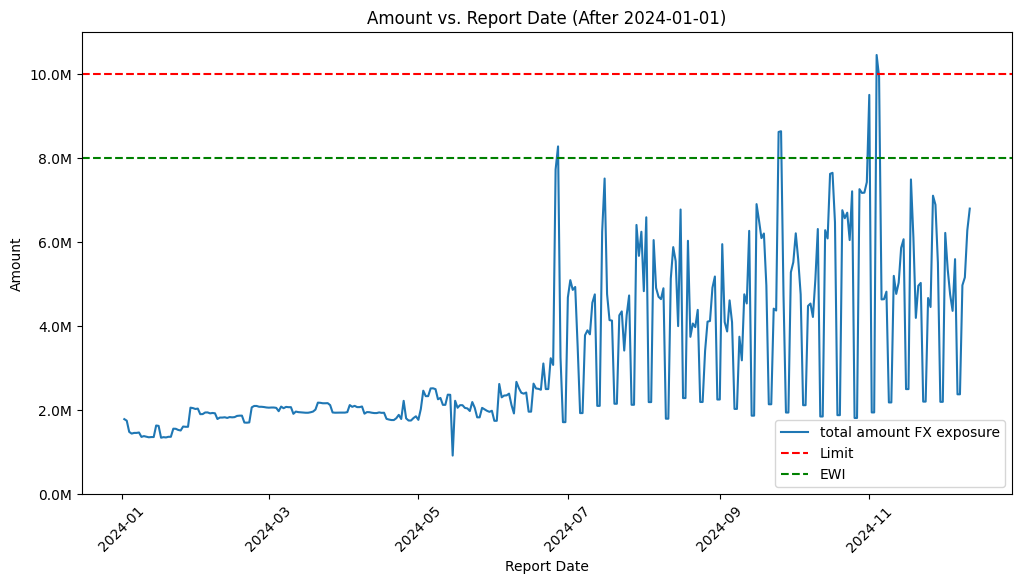

In [22]:
# Group the DataFrame by date and account_type, and sum the amount_in_euro
df_fx_total_filtered = df_fx_total[df_fx_total['report_date']>datetime(2024,1,1).date()]
grouped_df = df_fx_total_filtered.groupby(['report_date'])[['amount_in_euro']].sum()

df_tier1_filtered = df_tier1[df_tier1['report_date']>datetime(2024,1,1).date()]


plt.figure(figsize=(12, 6))  # Adjust width and height as needed
# Filter data for report dates after 01/01/2024

sns.lineplot(x='report_date', y='amount_in_euro', data=grouped_df, label='total amount FX exposure')
# sns.lineplot(x='report_date', y='fx_limit_exposure', data=df_tier1_filtered, label='fx limit exposure 2% T1Capital')

plt.title('Amount vs. Report Date (After 2024-01-01)')
# # Add horizontal lines for the limit and EWI
plt.axhline(y=10000000, color='r', linestyle='--', label='Limit')
plt.axhline(y=8000000, color='g', linestyle='--', label='EWI')
plt.xlabel('Report Date')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=45)

# Set y-axis limit to 10 million euros
plt.ylim(0, 11000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

In [23]:
grouped_df[grouped_df['amount_in_euro']>10000000]

,amount_in_euro
report_date,
2024-11-04,1.045466e+07


In [24]:
grouped_df[grouped_df['amount_in_euro']>8000000].shape

(6, 1)

In [9]:
pivot_table_fx_total = df_fx_total.pivot_table(values='amount_in_euro', index='report_date', columns='account_type', aggfunc='sum')
pivot_table_fx_total[['Corporate Transaction Accounts']]
pivot_table_fx_total.head(2)

account_type,Corporate Transaction Accounts,Securities Services Accounts,Trading Book Accounts
report_date,,,
2022-10-18,NaN,NaN,1.155739e+06
2022-10-19,NaN,NaN,1.160606e+06


In [10]:
pivot_table_fx_total[['Securities Services Accounts']][pivot_table_fx_total['Securities Services Accounts']>2700000].shape

(44, 1)

In [ ]:
# Group the DataFrame by date and account_type, and sum the amount_in_euro
grouped_df = df_fx_total.groupby(['report_date', 'account_type'])['amount_in_euro'].sum().unstack()

# Plot the grouped data
grouped_df.plot(figsize=(12, 6))
plt.xlabel('Report Date')
plt.ylabel('Amount in Euro')
plt.title('Amount by Account Type Over Time')
plt.legend(title='Account Type')
plt.grid(True)
# Set y-axis limit to 10 million euros
plt.ylim(0, 11000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

In [ ]:
# Plot the data
# plt.figure(figsize=(12, 6))
pivot_table_fx_total[['Securities Services Accounts']].plot(label='Securities Services Accounts',figsize=(12, 6))

# # Add horizontal lines for the limit and EWI
plt.axhline(y=3000000, color='r', linestyle='--', label='Limit')
plt.axhline(y=2700000, color='g', linestyle='--', label='EWI')

plt.xlabel('Report Date')
plt.ylabel('Amount in Euro')
plt.title('Securities Services Accounts Amount Over Time')
plt.legend()
plt.grid(True)
# Set y-axis limit to 10 million euros
plt.ylim(0, 11000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

In [11]:
pivot_table_fx_total[['Securities Services Accounts']][pivot_table_fx_total['Securities Services Accounts']>2700000].shape

(44, 1)

In [12]:
pivot_table_fx_total[['Securities Services Accounts']][pivot_table_fx_total['Securities Services Accounts']>3000000].shape

(38, 1)

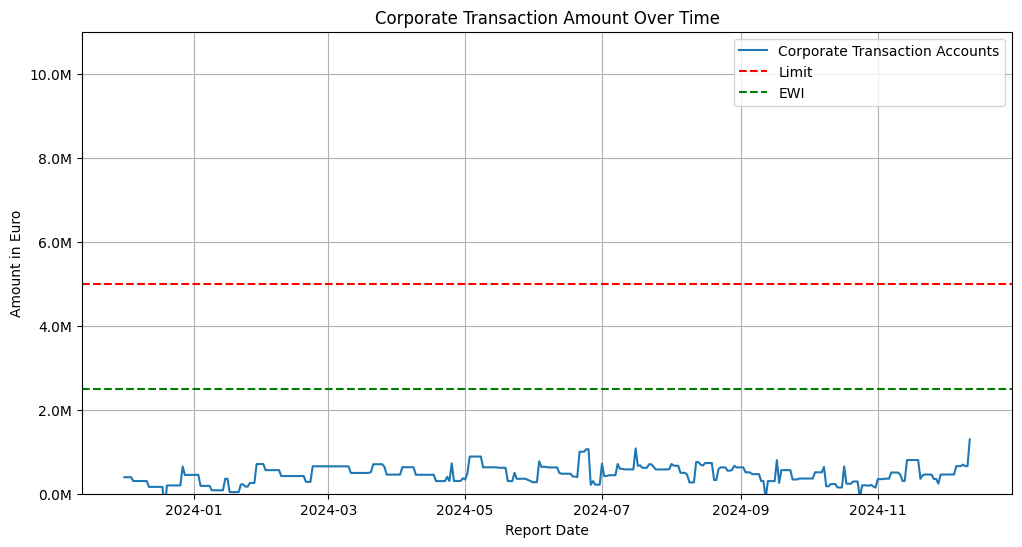

In [13]:
# Plot the data
# plt.figure(figsize=(12, 6))
pivot_table_fx_total[['Corporate Transaction Accounts']].plot(label='Corporate Transaction Amount',figsize=(12, 6))

# # Add horizontal lines for the limit and EWI
plt.axhline(y=5000000, color='r', linestyle='--', label='Limit')
plt.axhline(y=2500000, color='g', linestyle='--', label='EWI')



plt.xlabel('Report Date')
plt.ylabel('Amount in Euro')
plt.title('Corporate Transaction Amount Over Time')
plt.legend()
plt.grid(True)
# Set y-axis limit to 10 million euros
plt.ylim(0, 11000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

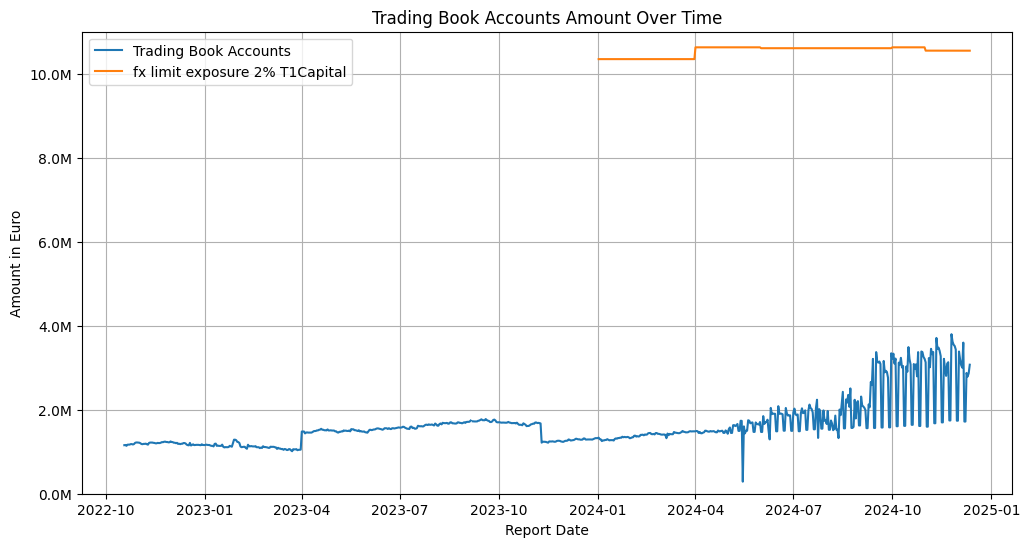

In [14]:
# Plot the data
# plt.figure(figsize=(12, 6))

pivot_table_fx_total[['Trading Book Accounts']].plot(label='Trading Book Accounts',figsize=(12, 6))
sns.lineplot(x='report_date', y='fx_limit_exposure', data=df_tier1_filtered, label='fx limit exposure 2% T1Capital')


# # Add horizontal lines for the limit and EWI
# plt.axhline(y=1000000, color='r', linestyle='--', label='Limit')
# plt.axhline(y=750000, color='g', linestyle='--', label='EWI')

plt.xlabel('Report Date')
plt.ylabel('Amount in Euro')
plt.title('Trading Book Accounts Amount Over Time')
plt.legend()
plt.grid(True)
# Set y-axis limit to 10 million euros
plt.ylim(0, 11000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

### Security services deep dive 

In [15]:
sql_query_security_services = """ --sql
--Clearstream accounts data is under message type 950, as a field named content
with full_data as (
    select
        "content" as content
    from
        BACKEND_PRD.SECURITIES_SERVICES_IO_MESSAGES.PUBLIC_IO_MESSAGE
    where
        "message_type" = '950'
        and "content" ilike '%:62F%'
),

extracted_fields as (
    select
        -- Extract the report_date (6 characters after :62F:C or :62F:D)
        case
            when position(':62F:C' in content) > 0 then
                to_date(substr(content, position(':62F:C' in content) + 6, 6), 'YYMMDD')
            when position(':62F:D' in content) > 0 then
                to_date(substr(content, position(':62F:D' in content) + 6, 6), 'YYMMDD')
        end as report_date,

        -- Extract the currency (3 characters after the report_date)
        case
            when position(':62F:C' in content) > 0 then
                substr(content, position(':62F:C' in content) + 12, 3)
            when position(':62F:D' in content) > 0 then
                substr(content, position(':62F:D' in content) + 12, 3)
        end as currency,

        -- Extract the original_amount, handle negative for :62F:D,
        -- and remove any non-numeric characters after the number, such as -} and }
        case
            when position(':62F:C' in content) > 0 then
                substr(content, position(':62F:C' in content) + 15,
                    least(position('-' in substr(content, position(':62F:C' in content) + 15)),
                          position('}' in substr(content, position(':62F:C' in content) + 15))) - 1)
            when position(':62F:D' in content) > 0 then
                substr(content, position(':62F:D' in content) + 15,
                    least(position('-' in substr(content, position(':62F:D' in content) + 15)),
                          position('}' in substr(content, position(':62F:D' in content) + 15))) - 1)
        end as amnt
    from
        full_data
    where
        position(':62F:C' in content) > 0 or position(':62F:D' in content) > 0
    qualify row_number() over (partition by report_date, currency order by report_date desc) = 1
)

select
    report_date,
    currency,
    cast(replace(replace(amnt, '.', ''), ',', '.') as decimal(18, 2)) * 1/data__ref_fx_rate.fx_rate as amount_in_euro,
    concat(
        'sec-',
        to_char(report_date, 'yyyymmdd'),
        '-',
        coalesce(to_char(currency), '')
    ) as surrogate_key
from
    extracted_fields
left join
    teams_prd.regulatory_reporting_mart.mrt_scd__regulatory_reporting__tbl_foreignexchangerate  as data__ref_fx_rate
        on extracted_fields.report_date = data__ref_fx_rate.report_dt
        and extracted_fields.currency = data__ref_fx_rate.ccy_code
where
    currency <> 'EUR'

"""
df_security_services = db.run_query(query=sql_query_security_services)
df_security_services.head(2)

Initiating login request with your identity provider. A browser window should have opened for you to complete the login. If you can't see it, check existing browser windows, or your OS settings. Press CTRL+C to abort and try again...
Going to open: https://traderepublic.okta.com/app/snowflake/exk18zobx3kssJFvx417/sso/saml?SAMLRequest=nZJPb%2BIwEMW%2FSuQ9J04CLWABFQWxpaItCpQVezPJQK0kdupxSNhPvw5%2Fqu6hPezNst%2FM73ne9O%2FqPHMOoFEoOSCB5xMHZKwSIfcD8rqaul3ioOEy4ZmSMCBHQHI37CPPs4KNSvMmI3gvAY1jG0lkzcOAlFoyxVEgkzwHZCZmy9HTnIWezzgiaGNx5FKSoLCsN2MKRmlVVV7V8pTe09D3fer3qFU1kh%2FkE6L4nlFoZVSssmtJbf%2F0BSKgfrtBWIUlLC6F90KeR%2FAdZXsWIXtYrRbu4mW5Is7o%2BruxkljmoJegDyKG12h%2BNoDWwc%2Bn226r0%2FGgdGOQRvPMDTyUqtplPIVY5UVpbGPPnugOEpqpvbDjmk0GpEhFMk43EpHP4vvNvLeJ9XG5iDbl3kRbbsp1Ha0f4vBXlL4%2FLjcxcdbXcMMm3BliCTPZRGrslR%2B23SB0g9Yq6LDQZze3Xvum95s4ExupkNycKq%2B%2BrdMENBTlNhOxp1LDTxZ5UdAP9xTqNOj%2BUdu6lSI%2BTg91O%2BhQREWb3Mh5ddjJhh7%2Bx0D69HODyyI%2B22xmk4Wyto7OVOmcm6%2BjC7zgdCMSd3eSMsi5yEZJogHRRphlqhpr4Mbuu9ElEDo8

/Users/fgv/Documents/Coding/repos/risk_pylibrary/tools/snowflake_db/db_connection.py:179: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,report_date,currency,amount_in_euro,surrogate_key
0,2023-05-23,SGD,1.376747,sec-20230523-SGD
1,2023-05-24,SGD,1.376842,sec-20230524-SGD


In [17]:
grouped_df = df_security_services.groupby(['report_date','currency'])['amount_in_euro'].sum().unstack()



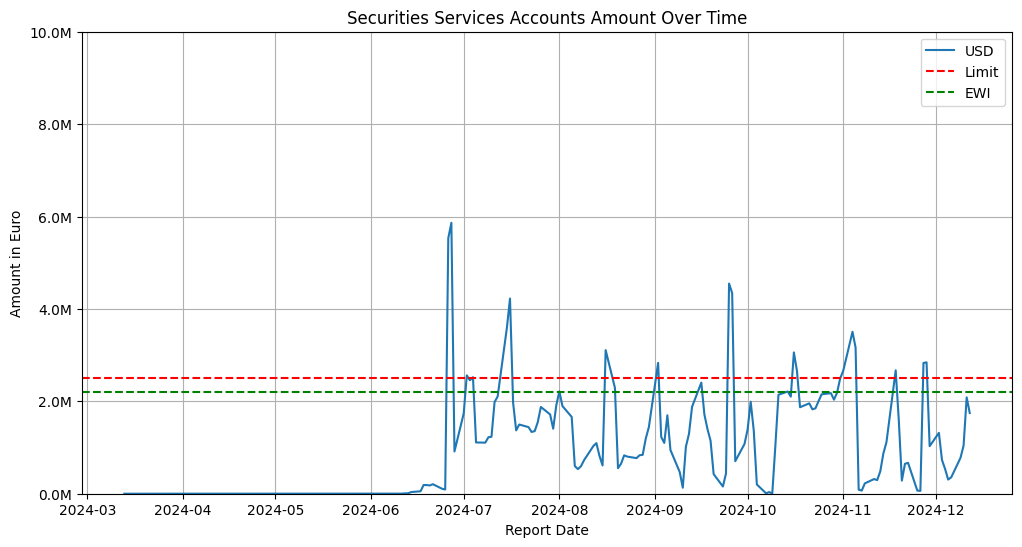

In [18]:


# Plot the data
# plt.figure(figsize=(12, 6))
grouped_df[['USD']].plot(label='Securities Services Accounts',figsize=(12, 6))

# # Add horizontal lines for the limit and EWI
plt.axhline(y=2500000, color='r', linestyle='--', label='Limit')
plt.axhline(y=2200000, color='g', linestyle='--', label='EWI')

plt.xlabel('Report Date')
plt.ylabel('Amount in Euro')
plt.title('Securities Services Accounts Amount Over Time')
plt.legend()
plt.grid(True)
# Set y-axis limit to 10 million euros
plt.ylim(0, 10000000)

# Format y-axis ticks as millions
plt.gca().yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'{x/1000000:.1f}M'))

plt.show()

In [19]:
grouped_df[grouped_df['USD']>2200000].shape

(24, 21)

In [20]:
grouped_df[grouped_df['USD']>2500000].shape

(18, 21)